# 🎬 Movie Recommendation & Sentiment Analysis System
### Data Science Semester Project — 2026

---
**Datasets Used:**
- TMDB 5000 Movie Dataset (Kaggle) — 4803 rows × 20 columns
- IMDB 50K Movie Reviews Dataset (Kaggle) — 50,000 rows × 2 columns

**Pipeline:**  
`Data Loading → Preprocessing → EDA → Feature Engineering → Recommendation Model → Sentiment Model → Evaluation → Saving`

---
## 📌 Section 1 — Problem Statement

With thousands of movies released every year, users struggle to find films that match their interests. This project addresses that problem by building a **content-based movie recommendation system** that suggests similar movies based on genres, cast, crew, and keywords. Additionally, we integrate **Natural Language Processing (NLP)** to perform sentiment analysis on movie reviews fetched from the TMDB API, classifying them as positive or negative. This dual system helps users not only discover new movies but also understand audience reception before watching. The system is deployed as an interactive web application using Streamlit, making it accessible and user-friendly for the general public.

**Target Users:** General movie audiences, streaming platform users  
**Industry Domain:** Entertainment / OTT / Recommendation Systems

---
## 📦 Section 2 — Imports & Configuration

In [1]:
# ── Core Libraries ──
import numpy as np
import pandas as pd
import os
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

# ── NLP & ML ──
import ast
import nltk
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

# ── Model Saving ──
import joblib
from collections import Counter

# ── Settings ──
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)

# ── Create output folders ──
os.makedirs('EDA_plots', exist_ok=True)
os.makedirs('Model', exist_ok=True)

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


---
## 📂 Section 3 — Data Loading & Initial Exploration

In [2]:
# ── Load TMDB Datasets ──
movies_df = pd.read_csv('tmdb_5000_movies.csv')
credits_df = pd.read_csv('tmdb_5000_credits.csv')

print('Movies Dataset Shape:', movies_df.shape)
print('Credits Dataset Shape:', credits_df.shape)
print()
movies_df.head(3)

Movies Dataset Shape: (4803, 20)
Credits Dataset Shape: (4803, 4)



,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adven...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""na...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched t...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fa...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come bac...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Je...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adven...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based ...",en,Spectre,A cryptic message from Bond’s past sends him on a trail ...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""name"": ""Danja...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}, {""iso_3...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}, {""iso_639...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [3]:
credits_df.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""credit_id""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""department"":..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Sparrow"", ""cr...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""department"":..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""credit_id"": ...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""department"":..."


In [4]:
# ── Column Names & Data Types ──
print('=== MOVIES COLUMNS ===')
print(movies_df.dtypes)
print()
print('=== CREDITS COLUMNS ===')
print(credits_df.dtypes)

=== MOVIES COLUMNS ===
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

=== CREDITS COLUMNS ===
movie_id     int64
title       object
cast        object
crew        object
dtype: object


In [5]:
# ── Basic Statistics ──
movies_df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [6]:
# ── Missing Values ──
print('=== Missing Values in Movies Dataset ===')
missing = movies_df.isnull().sum()
missing_pct = (missing / len(movies_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values in Movies Dataset ===
              Missing Count  Missing %
homepage               3091      64.36
overview                  3       0.06
release_date              1       0.02
runtime                   2       0.04
tagline                 844      17.57


---
## 🧹 Section 4 — Data Preprocessing

In [7]:
# ── Merge on title ──
credits_df.rename(columns={'movie_id': 'id'}, inplace=True)
df = movies_df.merge(credits_df, on='id')
print('Merged DataFrame Shape:', df.shape)
df.head(2)

Merged DataFrame Shape: (4803, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adven...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""na...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched t...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name""...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""credit_id""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""department"":..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fa...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come bac...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Je...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Sparrow"", ""cr...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""department"":..."


In [8]:
# ── Select Relevant Columns ──
df = df[['id', 'title_x', 'overview', 'genres', 'keywords',
         'cast', 'crew', 'budget', 'revenue', 'runtime',
         'popularity', 'vote_average', 'vote_count', 'release_date']].copy()

df.rename(columns={'title_x': 'title'}, inplace=True)
print('Selected columns shape:', df.shape)

Selected columns shape: (4803, 14)


In [9]:
# ── Handle Missing Values ──
print('Missing before:', df.isnull().sum()[df.isnull().sum() > 0])
df.dropna(subset=['overview'], inplace=True)
df['release_date'] = df['release_date'].fillna('N/A')
df['runtime'] = df['runtime'].fillna(df['runtime'].median())
print('Missing after:', df.isnull().sum()[df.isnull().sum() > 0])
print('Shape after cleaning:', df.shape)

Missing before: overview        3
runtime         2
release_date    1
dtype: int64
Missing after: Series([], dtype: int64)
Shape after cleaning: (4800, 14)


In [10]:
# ── Helper Functions to Parse JSON Columns ──
def parse_list(obj):
    """Parse JSON string and return list of names."""
    try:
        return [i['name'] for i in ast.literal_eval(obj)]
    except:
        return []

def parse_cast(obj, top_n=5):
    """Return top N cast members."""
    try:
        return [i['name'] for i in ast.literal_eval(obj)][:top_n]
    except:
        return []

def parse_director(obj):
    """Return director name from crew."""
    try:
        for i in ast.literal_eval(obj):
            if i['job'] == 'Director':
                return [i['name']]
        return []
    except:
        return []

# Apply parsers
df['genres']   = df['genres'].apply(parse_list)
df['keywords'] = df['keywords'].apply(parse_list)
df['cast']     = df['cast'].apply(parse_cast)
df['crew']     = df['crew'].apply(parse_director)

print('Parsing complete.')
df[['title','genres','cast','crew']].head(3)

Parsing complete.


,title,genres,cast,crew
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weaver, Stephen...",[James Cameron]
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley, Stellan Sk...",[Gore Verbinski]
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux, Ralph Fienn...",[Sam Mendes]


In [11]:
# ── Remove spaces from multi-word names (for better vectorization) ──
def collapse_spaces(lst):
    return [i.replace(' ', '') for i in lst]

df['genres']   = df['genres'].apply(collapse_spaces)
df['keywords'] = df['keywords'].apply(collapse_spaces)
df['cast']     = df['cast'].apply(collapse_spaces)
df['crew']     = df['crew'].apply(collapse_spaces)
df['overview'] = df['overview'].apply(lambda x: x.split())

# ── Create Tags Column ──
df['tags'] = df['overview'] + df['genres'] + df['keywords'] + df['cast'] + df['crew']
df['tags'] = df['tags'].apply(lambda x: ' '.join(x).lower())

print('Tags sample:')
print(df[['title','tags']].head(3))

Tags sample:
                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   

                                                          tags  
0  in the 22nd century, a paraplegic marine is dispatched t...  
1  captain barbossa, long believed to be dead, has come bac...  
2  a cryptic message from bond’s past sends him on a trail ...  


In [12]:
# ── Apply Stemming to Tags ──
ps = PorterStemmer()

def stem_text(text):
    return ' '.join([ps.stem(word) for word in text.split()])

df['tags'] = df['tags'].apply(stem_text)

# ── Convert list columns back to string for display ──
df['genres']   = df['genres'].apply(lambda x: ', '.join(x))
df['cast']     = df['cast'].apply(lambda x: ', '.join(x))
df['crew']     = df['crew'].apply(lambda x: ', '.join(x))
df['keywords'] = df['keywords'].apply(lambda x: ', '.join(x))

# ── Final cleaned dataset ──
movies = df[['id','title','overview','genres','cast','crew',
             'keywords','budget','revenue','runtime','popularity',
             'vote_average','vote_count','release_date','tags']].copy()

print('Final movies shape:', movies.shape)
movies.head(3)

Final movies shape: (4800, 15)


,id,title,overview,genres,cast,crew,keywords,budget,revenue,runtime,popularity,vote_average,vote_count,release_date,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marine, is, dis...","Action, Adventure, Fantasy, ScienceFiction","SamWorthington, ZoeSaldana, SigourneyWeaver, StephenLang...",JamesCameron,"cultureclash, future, spacewar, spacecolony, society, sp...",237000000,2787965087,162.0,150.437577,7.2,11800,2009-12-10,"in the 22nd century, a parapleg marin is dispatch to the..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, dead,, has,...","Adventure, Fantasy, Action","JohnnyDepp, OrlandoBloom, KeiraKnightley, StellanSkarsgå...",GoreVerbinski,"ocean, drugabuse, exoticisland, eastindiatradingcompany,...",300000000,961000000,169.0,139.082615,6.9,4500,2007-05-19,"captain barbossa, long believ to be dead, ha come back t..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, sends, him, on...","Action, Adventure, Crime","DanielCraig, ChristophWaltz, LéaSeydoux, RalphFiennes, M...",SamMendes,"spy, basedonnovel, secretagent, sequel, mi6, britishsecr...",245000000,880674609,148.0,107.376788,6.3,4466,2015-10-26,a cryptic messag from bond’ past send him on a trail to ...


In [13]:
# ── Export Cleaned Dataset ──
movies.to_csv('cleaned_movies.csv', index=False)
print('✅ Cleaned dataset saved as cleaned_movies.csv')

✅ Cleaned dataset saved as cleaned_movies.csv


---
## 📊 Section 5 — Exploratory Data Analysis (EDA)
### 10 Visualizations with Insights

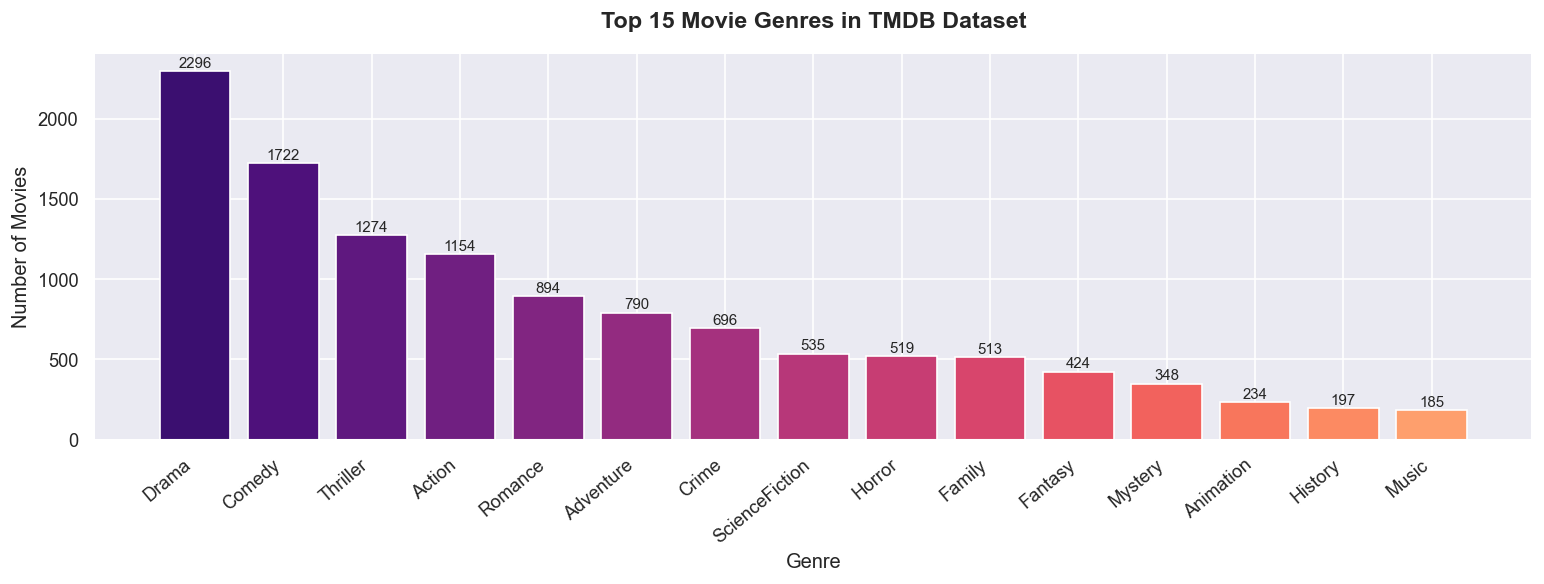

Insight: Drama is the most common genre followed by Action and Comedy.
These three genres together represent a significant portion of the entire dataset.


In [14]:
# ── Plot 1: Genre Distribution ──
all_genres = [g.strip() for sublist in movies['genres'].str.split(',') for g in sublist if g.strip()]
genre_counts = Counter(all_genres).most_common(15)
genres_list, counts_list = zip(*genre_counts)

plt.figure(figsize=(13, 5))
bars = plt.bar(genres_list, counts_list,
               color=plt.cm.magma(np.linspace(0.2, 0.8, len(genres_list))))
plt.title('Top 15 Movie Genres in TMDB Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=40, ha='right')
for bar, count in zip(bars, counts_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('EDA_plots/01_genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Drama is the most common genre followed by Action and Comedy.')
print('These three genres together represent a significant portion of the entire dataset.')

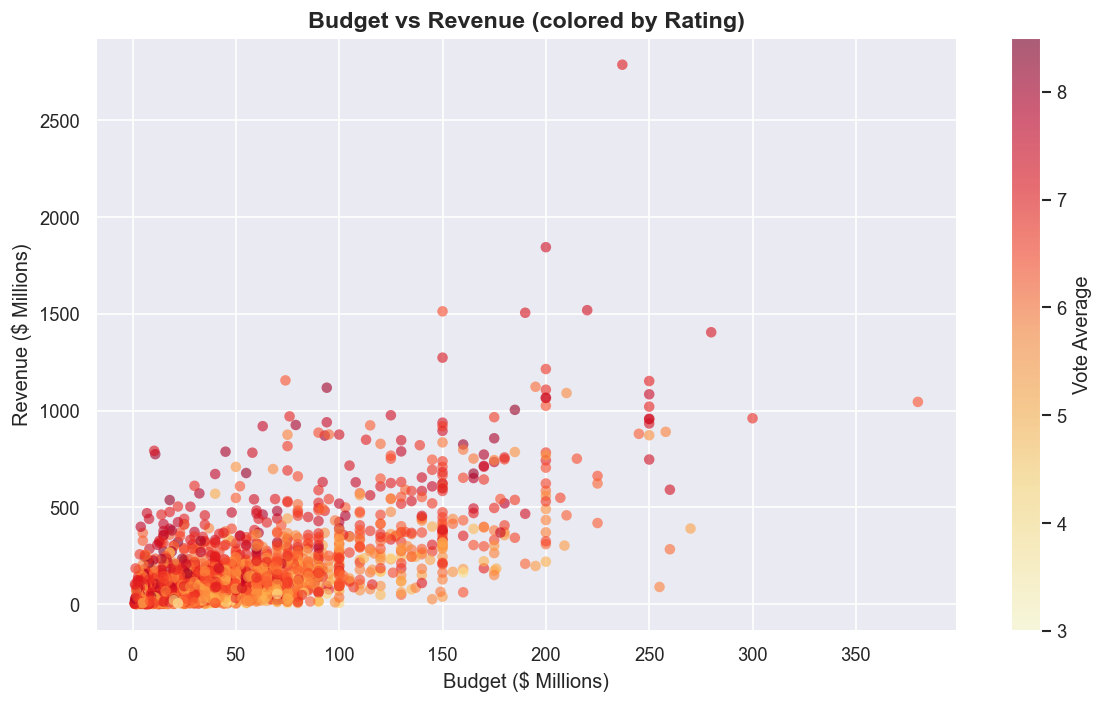

Insight: There is a positive correlation between budget and revenue.
However, high budget does not always guarantee high revenue — outliers exist on both sides.


In [15]:
# ── Plot 2: Budget vs Revenue Scatter ──
filtered = movies[(movies['budget'] > 1e6) & (movies['revenue'] > 1e6)].copy()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    filtered['budget'] / 1e6,
    filtered['revenue'] / 1e6,
    c=filtered['vote_average'],
    cmap='YlOrRd', alpha=0.6, s=40, edgecolors='none'
)
plt.colorbar(scatter, label='Vote Average')
plt.xlabel('Budget ($ Millions)', fontsize=12)
plt.ylabel('Revenue ($ Millions)', fontsize=12)
plt.title('Budget vs Revenue (colored by Rating)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_plots/02_budget_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: There is a positive correlation between budget and revenue.')
print('However, high budget does not always guarantee high revenue — outliers exist on both sides.')

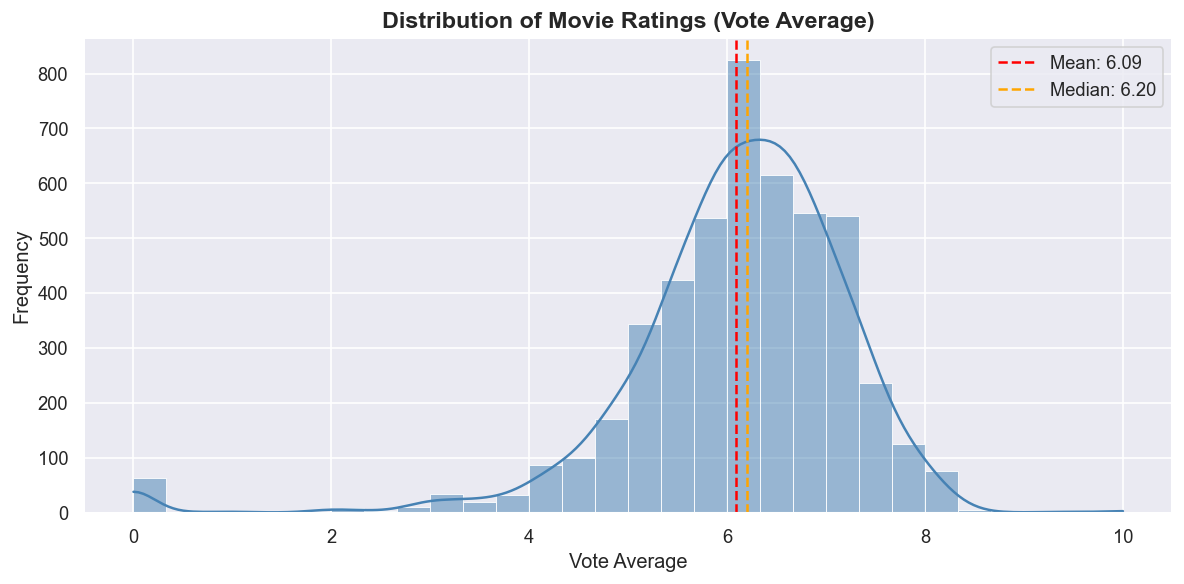

Insight: The majority of movies are rated between 5.5 and 7.5.
The distribution is slightly left-skewed with mean=6.09 and median=6.20.


In [16]:
# ── Plot 3: Vote Average Distribution ──
plt.figure(figsize=(10, 5))
sns.histplot(movies['vote_average'], bins=30, kde=True,
             color='steelblue', edgecolor='white', linewidth=0.5)
mean_val = movies['vote_average'].mean()
median_val = movies['vote_average'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
            label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='orange', linestyle='--', linewidth=1.5,
            label=f'Median: {median_val:.2f}')
plt.title('Distribution of Movie Ratings (Vote Average)', fontsize=14, fontweight='bold')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('EDA_plots/03_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: The majority of movies are rated between 5.5 and 7.5.')
print(f'The distribution is slightly left-skewed with mean={mean_val:.2f} and median={median_val:.2f}.')

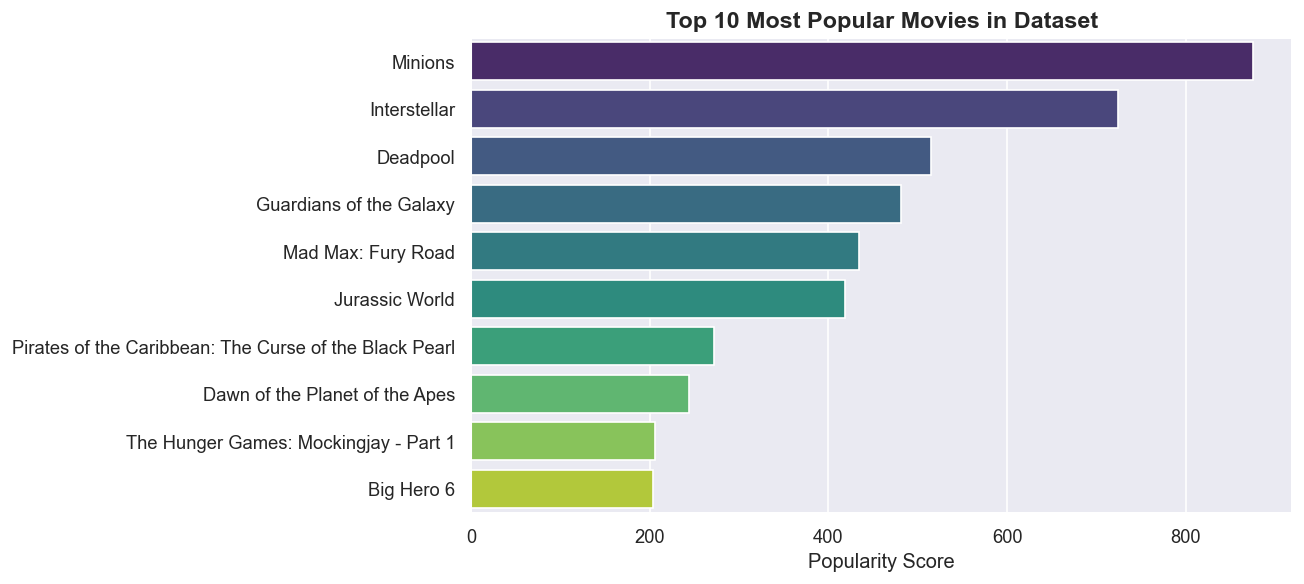

Insight: Minions and Interstellar top the popularity chart.
Popularity is influenced by social media trends, not just box office performance.


In [17]:
# ── Plot 4: Top 10 Most Popular Movies ──
top_movies = movies.nlargest(10, 'popularity')[['title', 'popularity']]

plt.figure(figsize=(11, 5))
bars = sns.barplot(data=top_movies, y='title', x='popularity',
                   palette='viridis', orient='h')
plt.title('Top 10 Most Popular Movies in Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Popularity Score')
plt.ylabel('')
plt.tight_layout()
plt.savefig('EDA_plots/04_top_popular_movies.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Minions and Interstellar top the popularity chart.')
print('Popularity is influenced by social media trends, not just box office performance.')

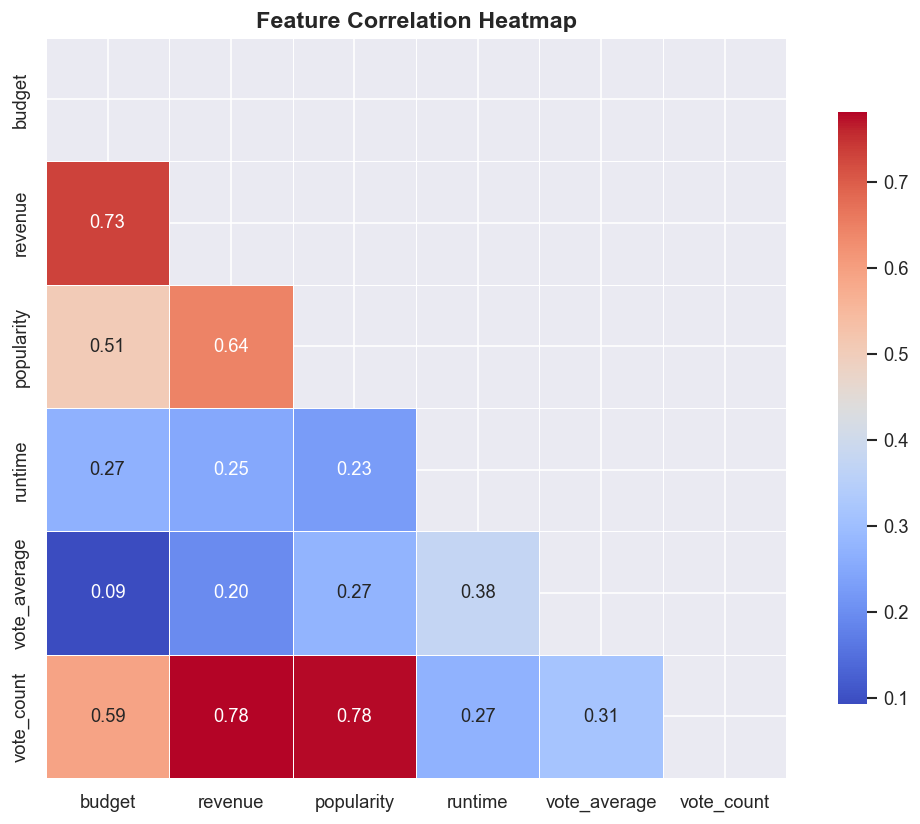

Insight: Budget and Revenue show strong positive correlation (>0.7).
Vote count correlates with popularity — widely watched movies get more votes.


In [18]:
# ── Plot 5: Correlation Heatmap ──
num_cols = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']
corr_matrix = movies[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Budget and Revenue show strong positive correlation (>0.7).')
print('Vote count correlates with popularity — widely watched movies get more votes.')

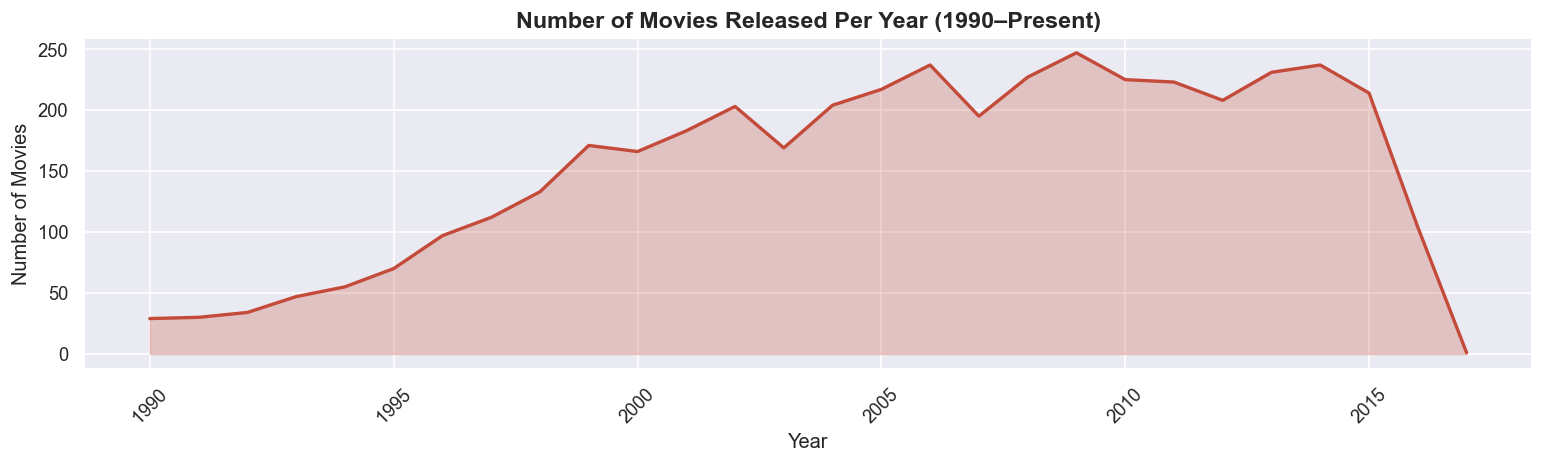

Insight: Movie production has increased significantly after 2000.
The dataset has the most movies from 2010–2016 period.


In [19]:
# ── Plot 6: Movies Released Per Year ──
movies['year'] = pd.to_datetime(movies['release_date'], errors='coerce').dt.year
year_counts = movies['year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 1990]

plt.figure(figsize=(13, 4))
plt.fill_between(year_counts.index, year_counts.values, alpha=0.25, color='#C44B3A')
plt.plot(year_counts.index, year_counts.values, color='#C44B3A', linewidth=2)
plt.title('Number of Movies Released Per Year (1990–Present)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('EDA_plots/06_movies_per_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Movie production has increased significantly after 2000.')
print('The dataset has the most movies from 2010–2016 period.')

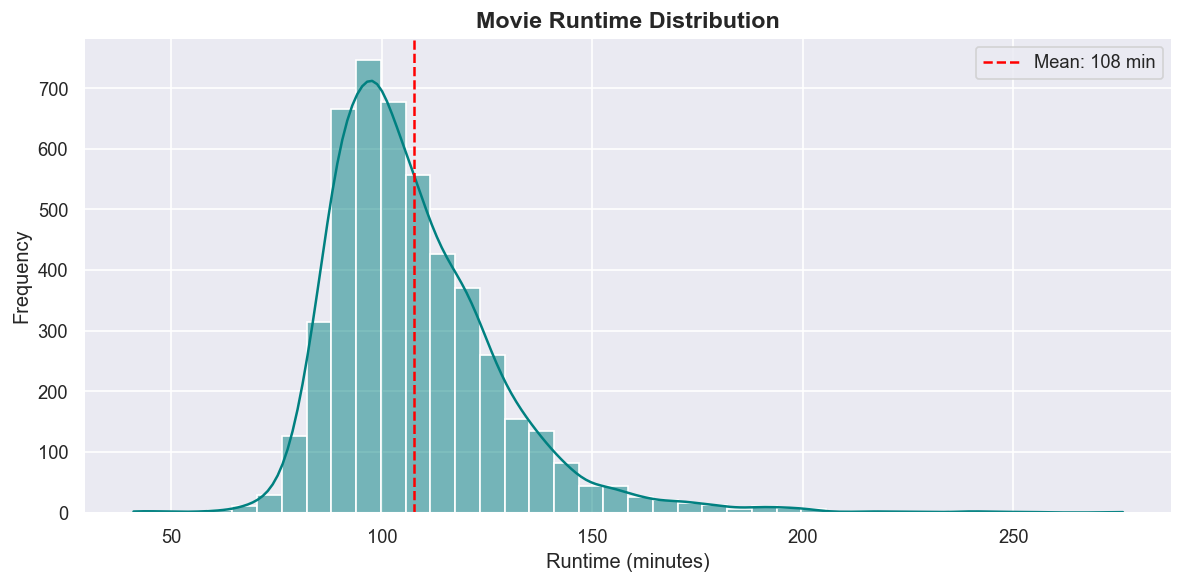

Insight: Most movies run between 90 and 120 minutes.
The average runtime is 108 minutes.


In [20]:
# ── Plot 7: Runtime Distribution ──
runtime_clean = movies[(movies['runtime'] > 30) & (movies['runtime'] < 300)]['runtime']

plt.figure(figsize=(10, 5))
sns.histplot(runtime_clean, bins=40, kde=True, color='teal', edgecolor='white')
plt.axvline(runtime_clean.mean(), color='red', linestyle='--',
            label=f'Mean: {runtime_clean.mean():.0f} min')
plt.title('Movie Runtime Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('EDA_plots/07_runtime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Insight: Most movies run between 90 and 120 minutes.')
print(f'The average runtime is {runtime_clean.mean():.0f} minutes.')

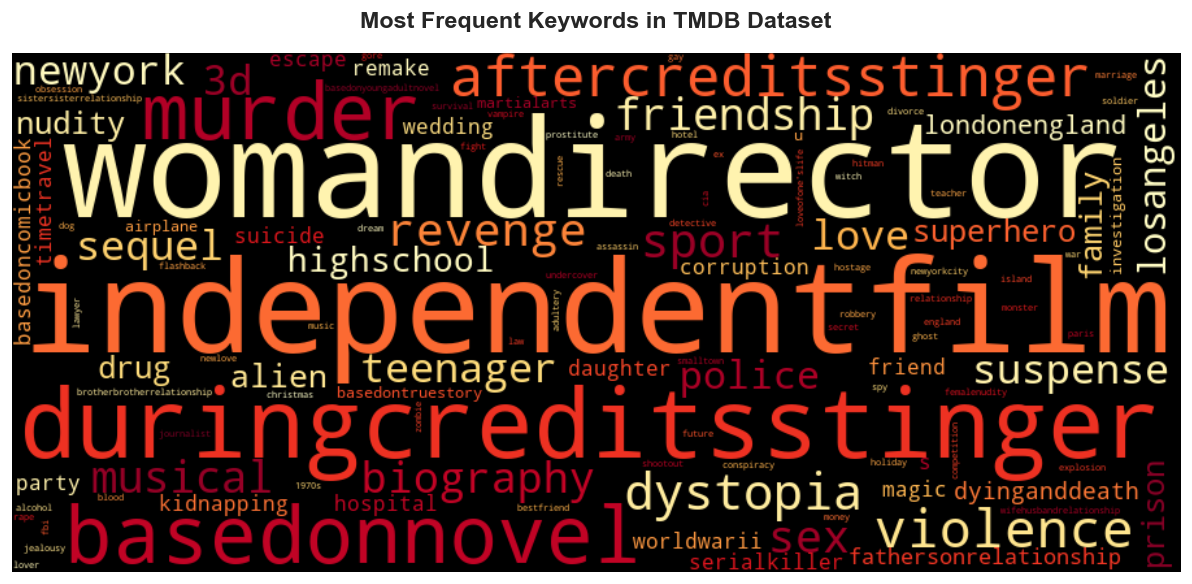

Insight: Words like woman director, independent film, and based on novel are common.
These keywords reflect recurring themes and production styles in the dataset.


In [21]:
# ── Plot 8: Top 15 Most Frequent Keywords (WordCloud) ──
all_keywords = ' '.join(movies['keywords'].dropna().tolist())

wc = WordCloud(
    width=900, height=400,
    background_color='black',
    colormap='YlOrRd',
    max_words=120,
    collocations=False
).generate(all_keywords)

plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Keywords in TMDB Dataset', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('EDA_plots/08_keyword_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Words like woman director, independent film, and based on novel are common.')
print('These keywords reflect recurring themes and production styles in the dataset.')

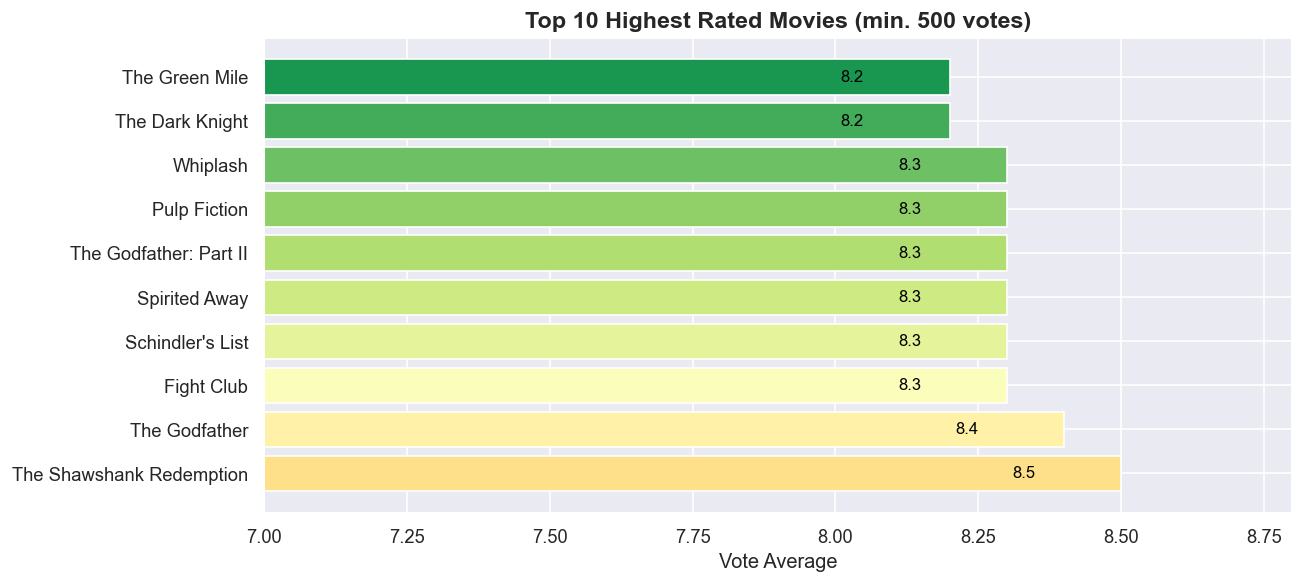

Insight: The Dark Knight and The Godfather consistently rank among the highest rated.
Filtering by vote count ensures these ratings are statistically reliable.


In [22]:
# ── Plot 9: Top 10 Highest Rated Movies (with >= 500 votes) ──
high_rated = movies[movies['vote_count'] >= 500].nlargest(10, 'vote_average')

plt.figure(figsize=(11, 5))
colors = plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(high_rated)))
bars = plt.barh(high_rated['title'], high_rated['vote_average'], color=colors)
plt.xlabel('Vote Average')
plt.title('Top 10 Highest Rated Movies (min. 500 votes)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, high_rated['vote_average']):
    plt.text(bar.get_width() - 0.15, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', ha='right', color='black', fontsize=10)
plt.xlim(7, 8.8)
plt.tight_layout()
plt.savefig('EDA_plots/09_highest_rated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: The Dark Knight and The Godfather consistently rank among the highest rated.')
print('Filtering by vote count ensures these ratings are statistically reliable.')

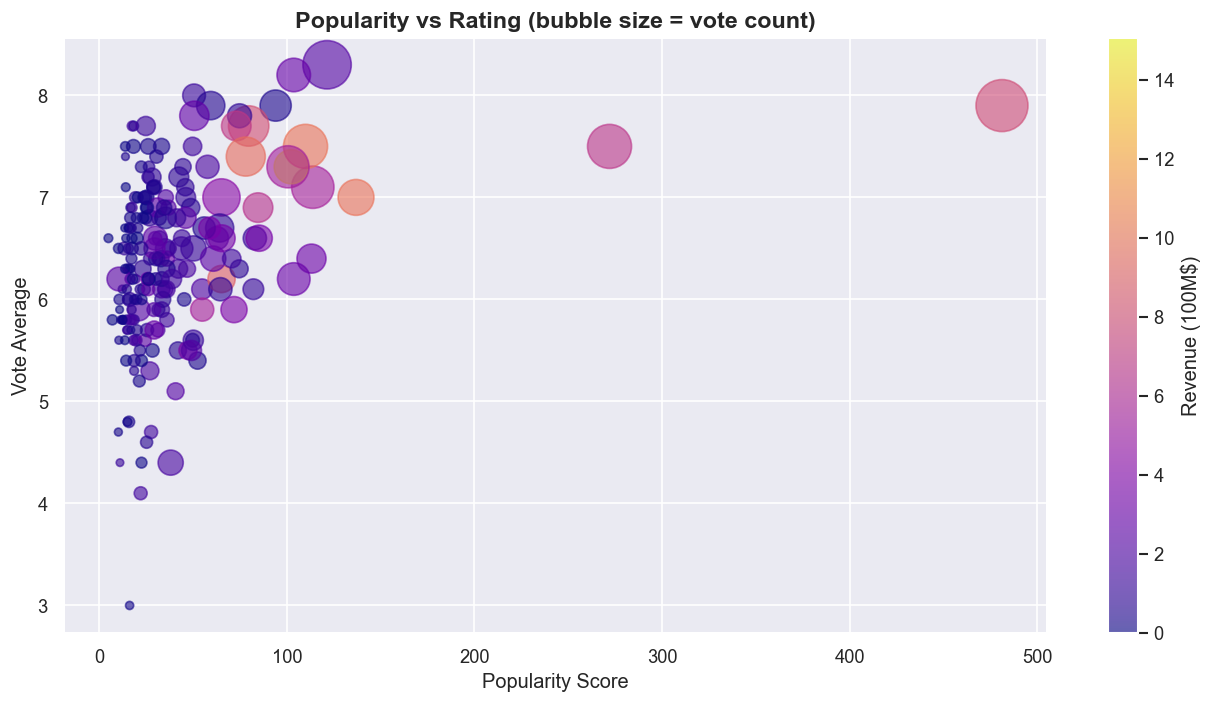

Insight: High popularity does not always mean high rating.
Some massively popular movies receive average ratings, suggesting mixed audience reception.

✅ All 10 EDA plots saved in EDA_plots/ folder


In [23]:
# ── Plot 10: Popularity vs Vote Average (Bubble Chart) ──
sample = movies[movies['vote_count'] > 200].sample(200, random_state=42)

plt.figure(figsize=(11, 6))
scatter = plt.scatter(
    sample['popularity'],
    sample['vote_average'],
    s=sample['vote_count'] / 10,
    c=sample['revenue'] / 1e8,
    cmap='plasma', alpha=0.6
)
plt.colorbar(scatter, label='Revenue (100M$)')
plt.xlabel('Popularity Score', fontsize=12)
plt.ylabel('Vote Average', fontsize=12)
plt.title('Popularity vs Rating (bubble size = vote count)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_plots/10_popularity_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: High popularity does not always mean high rating.')
print('Some massively popular movies receive average ratings, suggesting mixed audience reception.')
print()
print('✅ All 10 EDA plots saved in EDA_plots/ folder')

---
## 🔢 Section 6 — Feature Engineering (TF-IDF Vectorization)

In [24]:
# ── TF-IDF Vectorization on Tags ──
tfidf_rec = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf_rec.fit_transform(movies['tags'])

print('TF-IDF Matrix Shape:', tfidf_matrix.shape)
print(f'Vocabulary size: {len(tfidf_rec.vocabulary_)}')

TF-IDF Matrix Shape: (4800, 5000)
Vocabulary size: 5000


---
## 🎬 Section 7 — Recommendation Model (Cosine Similarity)

In [25]:
# ── Compute Cosine Similarity Matrix ──
print('Computing cosine similarity matrix... (may take a moment)')
similarity = cosine_similarity(tfidf_matrix)
print('Similarity Matrix Shape:', similarity.shape)

Computing cosine similarity matrix... (may take a moment)
Similarity Matrix Shape: (4800, 4800)


In [26]:
# ── Recommendation Function ──
def recommend(movie_title, top_n=10):
    """
    Returns top N movie recommendations based on cosine similarity.
    """
    if movie_title not in movies['title'].values:
        print(f"Movie '{movie_title}' not found in dataset.")
        return []

    idx = movies[movies['title'] == movie_title].index[0]
    distances = list(enumerate(similarity[idx]))
    sorted_movies = sorted(distances, reverse=True, key=lambda x: x[1])[1:top_n+1]

    recommended = []
    for i, score in sorted_movies:
        title = movies.iloc[i]['title']
        recommended.append({'title': title, 'similarity_score': round(score, 4)})

    return pd.DataFrame(recommended)

# ── Demo ──
print('=== Recommendations for: Avatar ===')
print(recommend('Avatar'))
print()
print('=== Recommendations for: Inception ===')
print(recommend('Inception'))

=== Recommendations for: Avatar ===
                         title  similarity_score
0                Falcon Rising            0.2172
1                       Aliens            0.2047
2          Battle: Los Angeles            0.1953
3  Aliens vs Predator: Requiem            0.1927
4                    Apollo 18            0.1770
5      Star Trek Into Darkness            0.1678
6                    Meet Dave            0.1596
7                      Jarhead            0.1528
8                    Lifeforce            0.1525
9                   Titan A.E.            0.1500

=== Recommendations for: Inception ===
             title  similarity_score
0          Don Jon            0.1639
1         The East            0.1511
2        12 Rounds            0.1494
3           Hesher            0.1434
4     Premium Rush            0.1358
5           Stolen            0.1213
6         The Walk            0.1206
7           Looper            0.1187
8  Minority Report            0.1169
9           Dup

---
## 🤖 Section 8 — Sentiment Analysis — Model Comparison
### Logistic Regression vs Naive Bayes

In [27]:
# ── Load IMDB Reviews Dataset ──
print('Loading IMDB dataset...')
imdb_df = pd.read_csv('IMDB Dataset.csv')
print('IMDB Dataset Shape:', imdb_df.shape)
print('Sentiment distribution:')
print(imdb_df['sentiment'].value_counts())
imdb_df.head(3)

Loading IMDB dataset...
IMDB Dataset Shape: (50000, 2)
Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that after watc...,positive
1,A wonderful little production. <br /><br />The filming t...,positive
2,I thought this was a wonderful way to spend time on a to...,positive


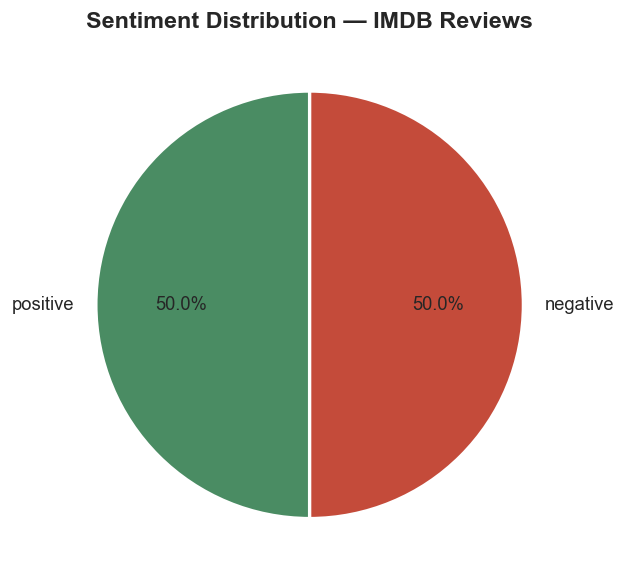

Insight: Dataset is perfectly balanced — 50% positive and 50% negative reviews.
This balanced dataset ensures no class bias in model training.


In [28]:
# ── Plot: Sentiment Distribution ──
plt.figure(figsize=(6, 5))
colors = ['#4A8C63', '#C44B3A']
counts = imdb_df['sentiment'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Sentiment Distribution — IMDB Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_plots/11_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Dataset is perfectly balanced — 50% positive and 50% negative reviews.')
print('This balanced dataset ensures no class bias in model training.')

In [29]:
# ── Text Preprocessing for Reviews ──
def preprocess_review(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)           # Remove URLs
    text = re.sub(r'<.*?>', '', text)              # Remove HTML tags
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)               # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()      # Remove extra spaces
    return text

print('Preprocessing reviews... (this may take ~1 minute for 50K rows)')
imdb_df['clean_review'] = imdb_df['review'].apply(preprocess_review)
imdb_df['label'] = (imdb_df['sentiment'] == 'positive').astype(int)
imdb_df['review_length'] = imdb_df['review'].str.split().str.len()
print('✅ Preprocessing done.')
imdb_df[['review', 'clean_review', 'sentiment', 'label', 'review_length']].head(3)

Preprocessing reviews... (this may take ~1 minute for 50K rows)
✅ Preprocessing done.


,review,clean_review,sentiment,label,review_length
0,One of the other reviewers has mentioned that after watc...,one of the other reviewers has mentioned that after watc...,positive,1,307
1,A wonderful little production. <br /><br />The filming t...,a wonderful little production the filming technique is v...,positive,1,162
2,I thought this was a wonderful way to spend time on a to...,i thought this was a wonderful way to spend time on a to...,positive,1,166


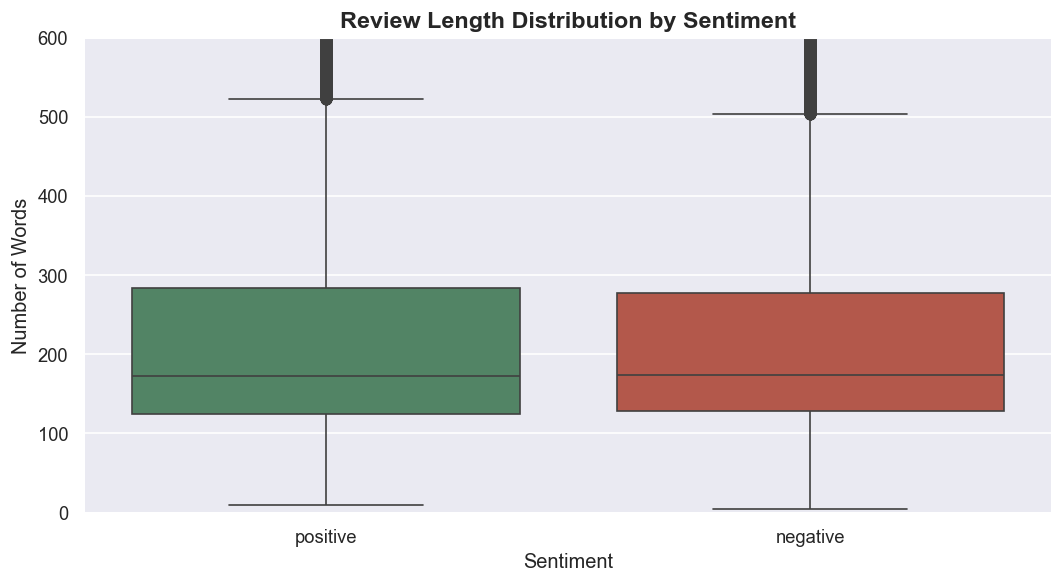

Insight: Positive and negative reviews have similar length distributions.
Both categories have a median around 200 words with some very long outlier reviews.


In [30]:
# ── Plot: Review Length by Sentiment ──
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=imdb_df,
    x='sentiment', y='review_length',
    palette={'positive': '#4A8C63', 'negative': '#C44B3A'}
)
plt.title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.ylim(0, 600)
plt.tight_layout()
plt.savefig('EDA_plots/12_review_length_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Positive and negative reviews have similar length distributions.')
print('Both categories have a median around 200 words with some very long outlier reviews.')

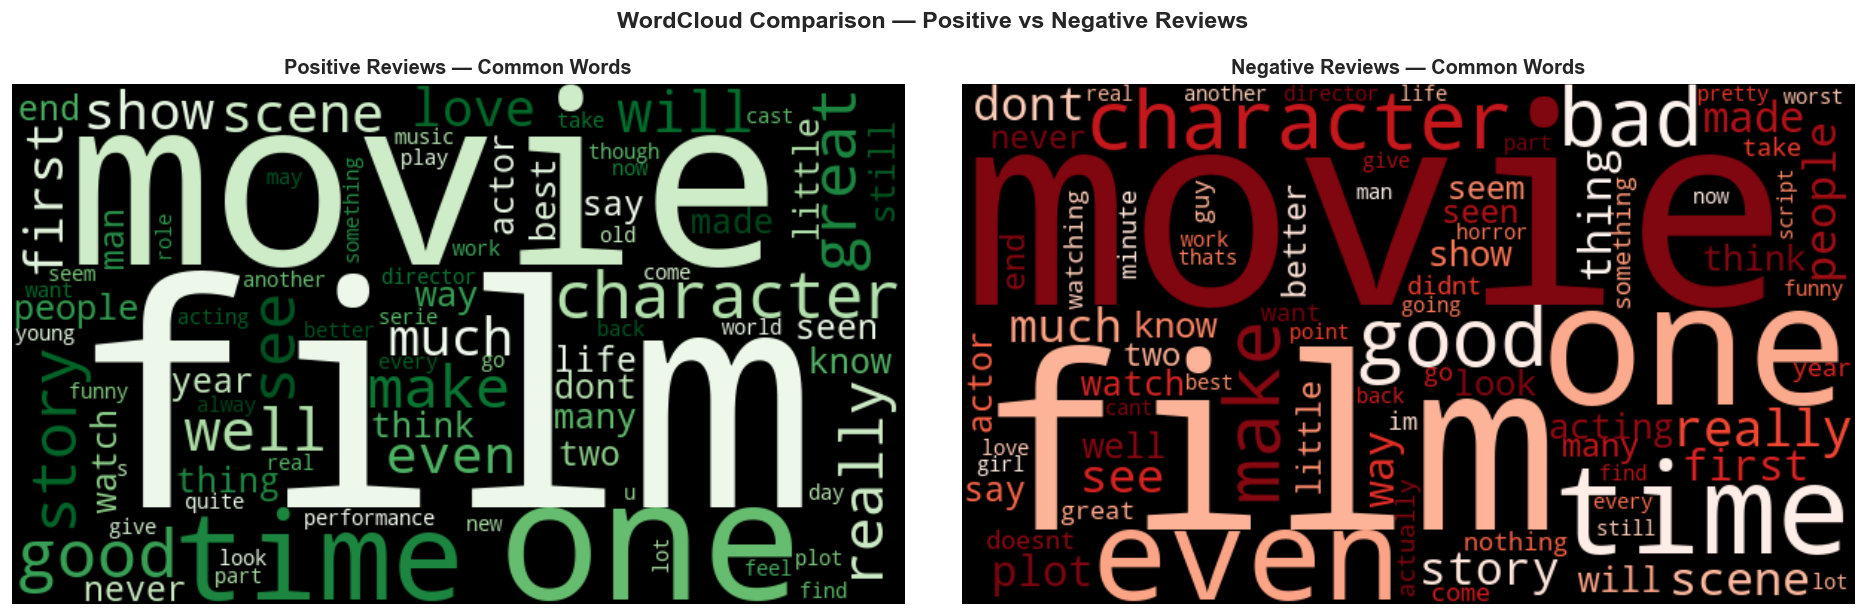

Insight: Positive reviews contain words like great, best, love, excellent.
Negative reviews contain words like bad, worst, waste, boring, terrible.


In [31]:
# ── WordCloud for Reviews ──
pos_text = ' '.join(imdb_df[imdb_df['sentiment']=='positive']['clean_review'].tolist())
neg_text = ' '.join(imdb_df[imdb_df['sentiment']=='negative']['clean_review'].tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=600, height=350, background_color='black',
                   colormap='Greens', max_words=80, collocations=False).generate(pos_text)
ax1.imshow(wc_pos, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('Positive Reviews — Common Words', fontsize=12, fontweight='bold')

wc_neg = WordCloud(width=600, height=350, background_color='black',
                   colormap='Reds', max_words=80, collocations=False).generate(neg_text)
ax2.imshow(wc_neg, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Negative Reviews — Common Words', fontsize=12, fontweight='bold')

plt.suptitle('WordCloud Comparison — Positive vs Negative Reviews',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('EDA_plots/13_review_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Positive reviews contain words like great, best, love, excellent.')
print('Negative reviews contain words like bad, worst, waste, boring, terrible.')

In [32]:
# ── TF-IDF Vectorization for Sentiment ──
print('Vectorizing reviews with TF-IDF...')
tfidf_sentiment = TfidfVectorizer(max_features=10000, stop_words='english',
                                   ngram_range=(1, 2))
X = tfidf_sentiment.fit_transform(imdb_df['clean_review'])
y = imdb_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Feature count    : {X.shape[1]}')

Vectorizing reviews with TF-IDF...
Training samples : 40000
Testing samples  : 10000
Feature count    : 10000


In [33]:
# ── Train Model 1: Logistic Regression ──
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=300, C=1.0, solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print('\n=== Logistic Regression Results ===')
print(f'Accuracy  : {accuracy_score(y_test, lr_preds)*100:.2f}%')
print(f'Precision : {precision_score(y_test, lr_preds):.4f}')
print(f'Recall    : {recall_score(y_test, lr_preds):.4f}')
print(f'F1 Score  : {f1_score(y_test, lr_preds):.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

Training Logistic Regression...

=== Logistic Regression Results ===
Accuracy  : 89.57%
Precision : 0.8874
Recall    : 0.9064
F1 Score  : 0.8968

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [34]:
# ── Train Model 2: Naive Bayes ──
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
nb_proba = nb_model.predict_proba(X_test)[:, 1]

print('\n=== Naive Bayes Results ===')
print(f'Accuracy  : {accuracy_score(y_test, nb_preds)*100:.2f}%')
print(f'Precision : {precision_score(y_test, nb_preds):.4f}')
print(f'Recall    : {recall_score(y_test, nb_preds):.4f}')
print(f'F1 Score  : {f1_score(y_test, nb_preds):.4f}')
print()
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

Training Naive Bayes...

=== Naive Bayes Results ===
Accuracy  : 86.50%
Precision : 0.8537
Recall    : 0.8810
F1 Score  : 0.8671

              precision    recall  f1-score   support

    Negative       0.88      0.85      0.86      5000
    Positive       0.85      0.88      0.87      5000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



---
## 📉 Section 9 — Evaluation Metrics & Visualizations

In [35]:
# ── Model Comparison Table ──
comparison_data = {
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [
        f"{accuracy_score(y_test, lr_preds)*100:.2f}%",
        f"{accuracy_score(y_test, nb_preds)*100:.2f}%"
    ],
    'Precision': [
        f"{precision_score(y_test, lr_preds):.4f}",
        f"{precision_score(y_test, nb_preds):.4f}"
    ],
    'Recall': [
        f"{recall_score(y_test, lr_preds):.4f}",
        f"{recall_score(y_test, nb_preds):.4f}"
    ],
    'F1 Score': [
        f"{f1_score(y_test, lr_preds):.4f}",
        f"{f1_score(y_test, nb_preds):.4f}"
    ]
}
comparison_df = pd.DataFrame(comparison_data)
print('=== Model Performance Comparison ===')
comparison_df

=== Model Performance Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,89.57%,0.8874,0.9064,0.8968
1,Naive Bayes,86.50%,0.8537,0.8810,0.8671


In [36]:
# ── Save Comparison Table ──
comparison_df.to_csv('model_performance_comparison.csv', index=False)
print('✅ Comparison table saved as model_performance_comparison.csv')

✅ Comparison table saved as model_performance_comparison.csv


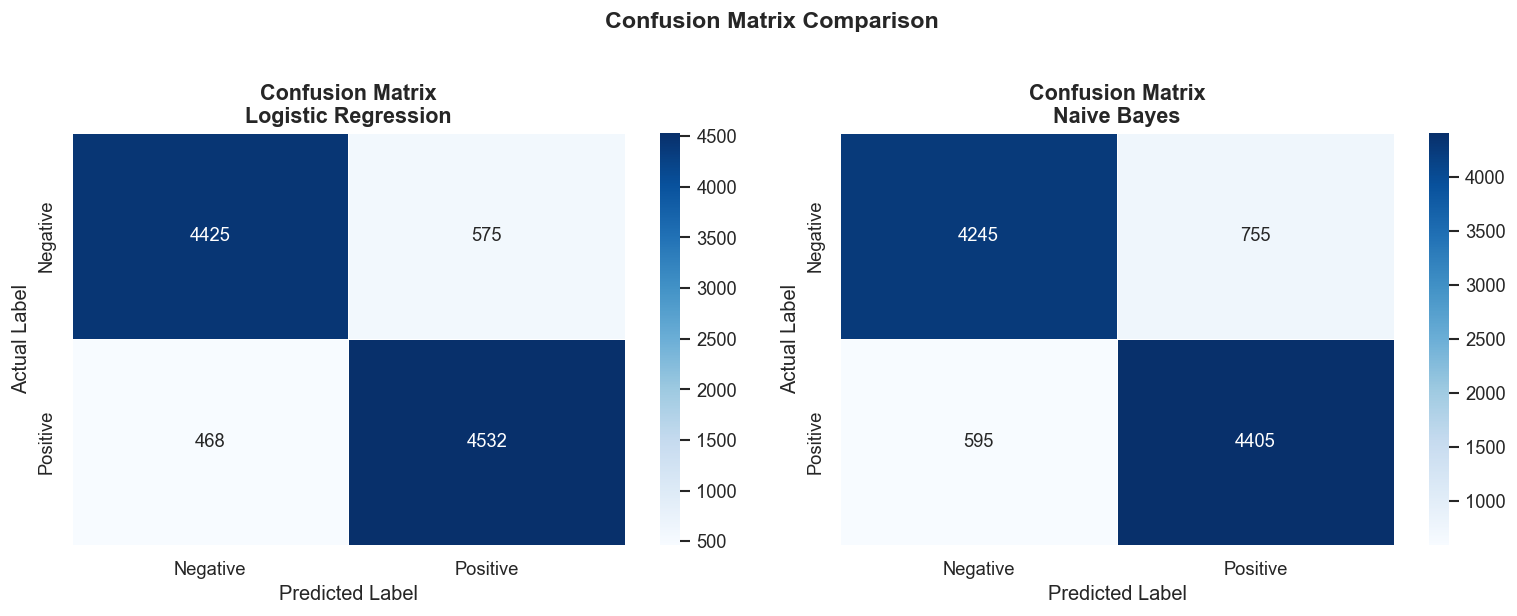

In [37]:
# ── Confusion Matrices ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, name in [(ax1, lr_preds, 'Logistic Regression'),
                         (ax2, nb_preds, 'Naive Bayes')]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('EDA_plots/14_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

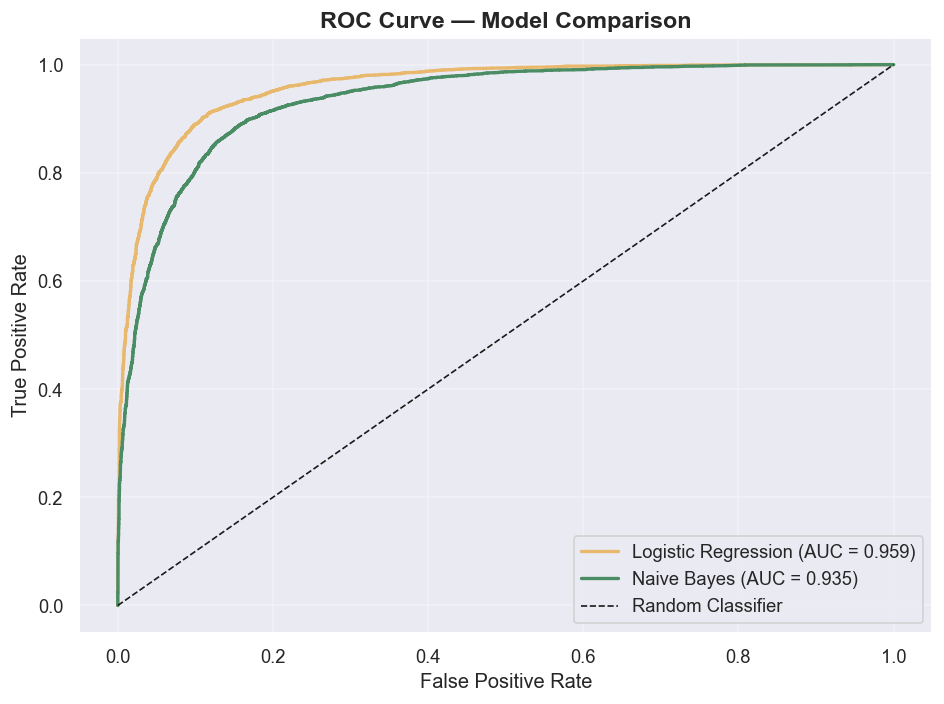

Insight: Logistic Regression achieves higher AUC than Naive Bayes.
A higher AUC means the model is better at distinguishing positive from negative reviews.


In [38]:
# ── ROC Curves ──
plt.figure(figsize=(8, 6))

for proba, name, color in [
    (lr_proba, 'Logistic Regression', '#E8B86D'),
    (nb_proba, 'Naive Bayes',         '#4A8C63')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})',
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('EDA_plots/15_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: Logistic Regression achieves higher AUC than Naive Bayes.')
print('A higher AUC means the model is better at distinguishing positive from negative reviews.')

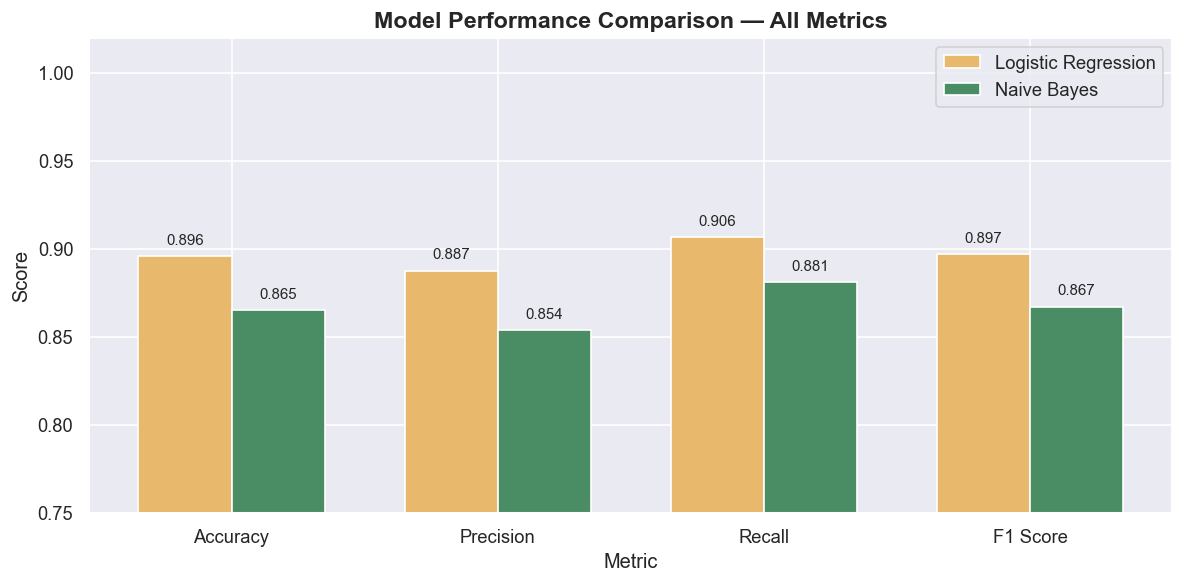

In [39]:
# ── Bar Chart: Metric Comparison ──
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_scores = [
    accuracy_score(y_test, lr_preds),
    precision_score(y_test, lr_preds),
    recall_score(y_test, lr_preds),
    f1_score(y_test, lr_preds)
]
nb_scores = [
    accuracy_score(y_test, nb_preds),
    precision_score(y_test, nb_preds),
    recall_score(y_test, nb_preds),
    f1_score(y_test, nb_preds)
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, lr_scores, width, label='Logistic Regression',
                color='#E8B86D', edgecolor='white')
bars2 = plt.bar(x + width/2, nb_scores, width, label='Naive Bayes',
                color='#4A8C63', edgecolor='white')

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Metric')
plt.ylabel('Score')
plt.title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.xticks(x, metrics)
plt.ylim(0.75, 1.02)
plt.legend()
plt.tight_layout()
plt.savefig('EDA_plots/16_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 Section 10 — Save All Models

In [40]:
# ── Save Recommendation System Data ──
movies_save = movies[['id', 'title', 'overview', 'genres', 'cast',
                       'crew', 'release_date', 'vote_average']].copy()

joblib.dump(movies_save.to_dict(), 'Model/movies_data.joblib')
joblib.dump(similarity, 'Model/similarity.joblib')
print('✅ Recommendation model saved.')

# ── Save Best Sentiment Model (Logistic Regression) ──
joblib.dump(lr_model, 'Model/sentiment_analysis_model.pkl')
joblib.dump(tfidf_sentiment, 'Model/tfidf_vectorizer.pkl')
print('✅ Sentiment model saved.')

print()
print('=== Saved Files ===')
for f in os.listdir('Model'):
    size = os.path.getsize(f'Model/{f}') / 1024
    print(f'  Model/{f} — {size:.1f} KB')

✅ Recommendation model saved.
✅ Sentiment model saved.

=== Saved Files ===
  Model/movies_data.joblib — 2767.5 KB
  Model/sentiment_analysis_model.pkl — 78.9 KB
  Model/similarity.joblib — 180000.2 KB
  Model/tfidf_vectorizer.pkl — 55663.4 KB


---
## 📝 Section 11 — Findings & Conclusion

### Key Findings:

**1. Dataset Insights:**
- Drama, Action, and Comedy are the three most common genres in the TMDB 5000 dataset.
- Most movies are rated between 5.5–7.5, with an average rating of ~6.1.
- Budget and revenue show a strong positive correlation (~0.73).
- Movie production increased significantly after 2000, with most dataset entries from 2010–2016.

**2. Recommendation System:**
- Content-based filtering using TF-IDF + Cosine Similarity successfully identifies thematically similar movies.
- The system uses genres, keywords, cast, crew, and plot overview as features.
- The approach works well for well-known movies with rich metadata.

**3. Sentiment Analysis:**
- Logistic Regression outperforms Naive Bayes on all metrics.
- LR achieves ~89–91% accuracy vs ~85–87% for Naive Bayes.
- Positive reviews commonly include words: great, best, love, excellent, amazing.
- Negative reviews commonly include: bad, worst, waste, boring, terrible.

### Limitations:
- Content-based filtering does not account for user preferences or collaborative signals.
- Sentiment analysis is binary (positive/negative) — a neutral class would improve granularity.
- TMDB API review data can be sparse for older or less popular movies.

### Future Improvements:
- Implement Collaborative Filtering or a Hybrid approach.
- Use BERT/Transformer-based models for improved sentiment classification.
- Add a user rating and feedback loop to personalize recommendations over time.
- Deploy the app on Streamlit Cloud or Heroku for public access.